In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [12]:
# define state

class LLM_QA(TypedDict):
    query:str
    response:str


In [13]:
# Node Function
import os
from dotenv import load_dotenv
load_dotenv()
from openai import OpenAI
from langchain_groq import ChatGroq

model = ChatGroq( model="openai/gpt-oss-20b", api_key=os.environ.get("GROQ_API_KEY"))

def llm_res(state:LLM_QA) -> LLM_QA:
    query = state["query"]

    prompt=f"answer the following questions: {query}"

    state["response"] = model.invoke(prompt).content

    return state


e:\Langchain\langchain-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Define your graph

graph = StateGraph(LLM_QA)

# nodes

graph.add_node('llm_res',llm_res)

# edges

graph.add_edge(START,'llm_res')
graph.add_edge('llm_res',END)


# compile

workflow = graph.compile()



In [15]:
# Execute the graph
initial_state = {'query':'who is virat kohli ?'}
workflow.invoke(initial_state)

{'query': 'who is virat kohli ?',
 'response': '**Virat Kohli** is an Indian international cricketer widely regarded as one of the greatest batsmen of his era. Born on 5\u202fNovember 1988 in Delhi, India, he rose through the ranks of domestic cricket to make his ODI debut in 2008. Kohli captained India in all three formats (ODI, T20I, and Test) from 2014 to 2022, leading the team to numerous historic victories, including the 2018–19 ICC World Test Championship title and the 2019 ICC Cricket World Cup.\n\nKey highlights:\n\n- **Batting prowess**: Known for his aggressive style, consistency, and ability to chase down totals. He has scored over 12,000 runs in ODIs, 11,000+ in Tests, and 7,000+ in T20Is, with numerous centuries and double‑centuries across formats.\n- **Leadership**: Under his captaincy, India achieved a number of significant milestones, such as becoming the first team to win a series in Australia (2018–19) and winning the ICC World Test Championship.\n- **Awards**: He has

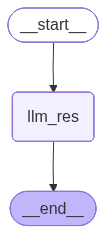

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())